> Initialising Popstar models (IMF='cha')
--> Only stellar continuum
Computing synthetic photometry for SSP model


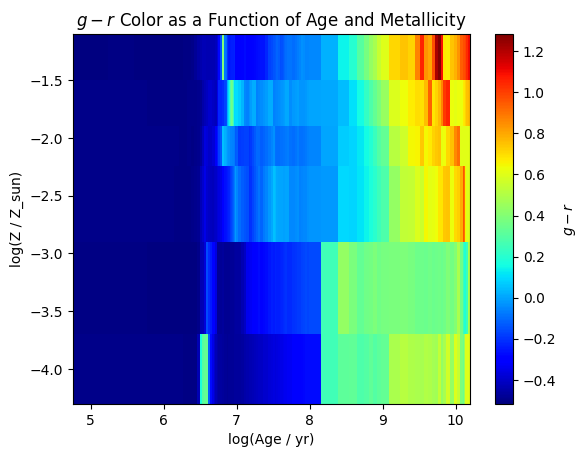

In [1]:
from pst.SSP import PopStar
from pst.observables import load_photometric_filters
import numpy as np
from matplotlib import pyplot as plt

# Define the IMF and redshift
imf_type = 'cha'  # Chabrier 2003 Initial Mass Function
z_redshift = 0.0  # Redshift at which the SSPs are observed

# Load photometric filters (g and r bands)
list_of_filter_names = ["SLOAN_SDSS.g", "SLOAN_SDSS.r"]
filters = load_photometric_filters(list_of_filter_names)

# Initialize the SSP model
ssp_model = PopStar(IMF=imf_type)

# Compute photometry for the SSPs in the selected filters
photometry_fluxes = ssp_model.compute_photometry(filter_list=filters,
                                                 z_obs=z_redshift)

# Convert fluxes to AB magnitudes
magnitudes = -2.5 * np.log10(photometry_fluxes.to_value("3631 Jy / Msun"))

# Compute g - r color
color = magnitudes[0] - magnitudes[1]

# Plot the color as a function of stellar age and metallicity
plt.figure()
plt.pcolormesh(np.log10(ssp_model.ages.value),
               np.log10(ssp_model.metallicities.value), color,
               cmap='jet')
plt.colorbar(label=r'$g - r$')
plt.xlabel('log(Age / yr)')
plt.ylabel('log(Z / Z_sun)')
plt.title(r'$g - r$ Color as a Function of Age and Metallicity')
plt.show()